# AG News Auto-Triage: Deep Learning for Business Operations
## Table of Contents
1. [Business Problem & Dataset Description](#1-business-problem--dataset-description)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Preprocessing Pipeline](#3-preprocessing-pipeline)
4. [Model from Scratch (Keras)](#4-model-from-scratch-keras)
5. [Pretrained Model (DistilBERT)](#5-pretrained-model-distilbert)
6. [Hyperparameter Tuning](#6-hyperparameter-tuning)
7. [Model Evaluation & Interpretation](#7-model-evaluation--interpretation)
8. [Final Report](#8-final-report)

# 1. Business Problem & Dataset Description
## 1.1 Business Context
- A financial services firm receives 5,000 news articles daily.
- Analysts manually route each article to World, Sports, Business, or Sci/Tech desks.
- Time per article: 90 seconds. Analyst rate: $35/hour. Trading days: 250/year.
- Total labor cost: 5,000 × 90s × $35/hr × 250 days = $1.09M/year.
- A DL model automating 85% of routing saves ~$930K/year.

## 1.2 Dataset Reference
- Source: https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset/data
- 120,000 training samples, 7,600 test samples.
- 4 classes: World, Sports, Business, Sci/Tech.
- Features: article title + description (text), label (0-3).

In [1]:
# Imports and environment setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Allow importing from src/ folder
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Also make file paths in the notebook resolve from the project root,
# so 'data/train.csv', 'models/...', 'reports/...' all work.
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Working dir : {os.getcwd()}")

# Verify environment
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

Project root: h:\Programming\Python\AppliedMathProject\math4dl_project
Working dir : h:\Programming\Python\AppliedMathProject\math4dl_project
TensorFlow version: 2.10.1
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Exploratory Data Analysis

## 2.1 Load Data

In [2]:
# We load the CSVs saved by src/setup_data.py
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print("=== TRAIN SET ===")
print(train_df.head(2))
print(f"\nShape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")

print("\n=== TEST SET ===")
print(test_df.head(2))
print(f"\nShape: {test_df.shape}")


=== TRAIN SET ===
   class_index                                              title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   

                                         description  category  
0  Reuters - Short-sellers, Wall Street's dwindli...  Business  
1  Reuters - Private investment firm Carlyle Grou...  Business  

Shape: (120000, 4)

Columns: ['class_index', 'title', 'description', 'category']

=== TEST SET ===
   class_index                                              title  \
0            3                  Fears for T N pension after talks   
1            4  The Race is On: Second Private Team Sets Launc...   

                                         description  category  
0  Unions representing workers at Turner   Newall...  Business  
1  SPACE.com - TORONTO, Canada -- A second\team o...  Sci/Tech  

Shape: (7600, 4)


## 2.2 Class Distribution

In [3]:
print(train_df.columns)

Index(['class_index', 'title', 'description', 'category'], dtype='object')


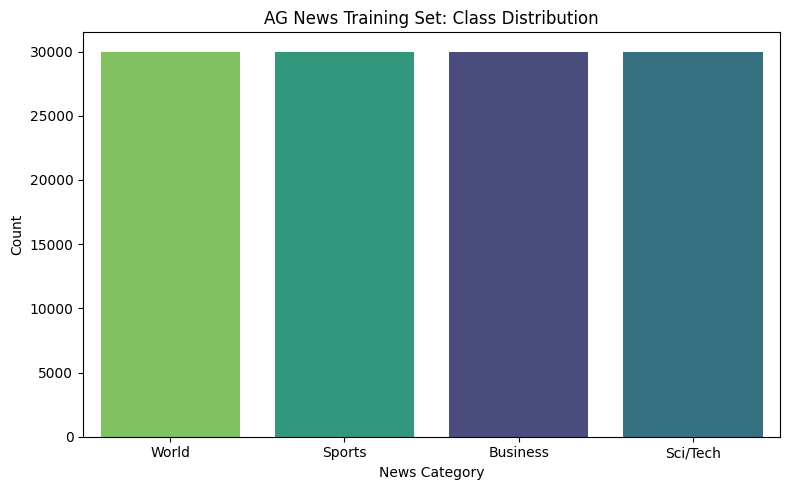


Class counts (train):
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [4]:
# Visualize how balanced the dataset is
plt.figure(figsize=(8, 5))
order = ['World', 'Sports', 'Business', 'Sci/Tech']
sns.countplot(
    data=train_df,
    x='category',
    order=order,
    hue='category',
    palette='viridis',
    legend=False,
)
plt.title('AG News Training Set: Class Distribution')
plt.xlabel('News Category')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('reports/class_distribution.png')
plt.show()

print("\nClass counts (train):")
print(train_df['category'].value_counts())


## 2.3 Text Length Analysis

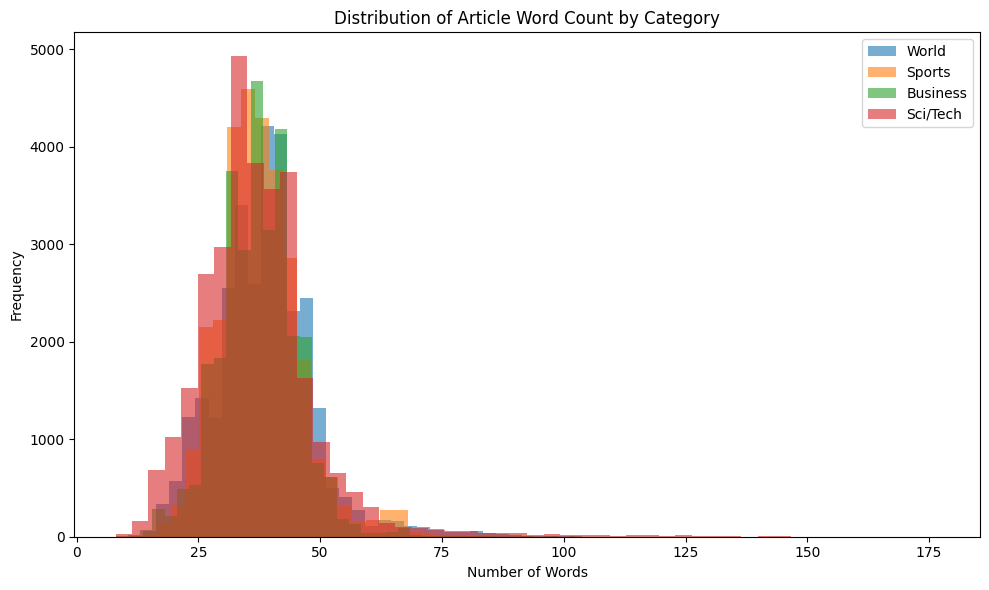


Average word count per category:
category
Business    37.5
Sci/Tech    37.2
Sports      37.8
World       38.9
Name: word_count, dtype: float64


In [5]:
# Combine title + description for full article text
train_df['full_text'] = train_df['title'].astype(str) + ' ' + train_df['description'].astype(str)
test_df['full_text'] = test_df['title'].astype(str) + ' ' + test_df['description'].astype(str)

# Calculate length in words
train_df['word_count'] = train_df['full_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
for category in order:
    subset = train_df[train_df['category'] == category]['word_count']
    plt.hist(subset, bins=50, alpha=0.6, label=category)
plt.title('Distribution of Article Word Count by Category')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('reports/word_count_distribution.png')
plt.show()

print(f"\nAverage word count per category:")
print(train_df.groupby('category')['word_count'].mean().round(1))


## 2.4 Word Clouds / Common Words

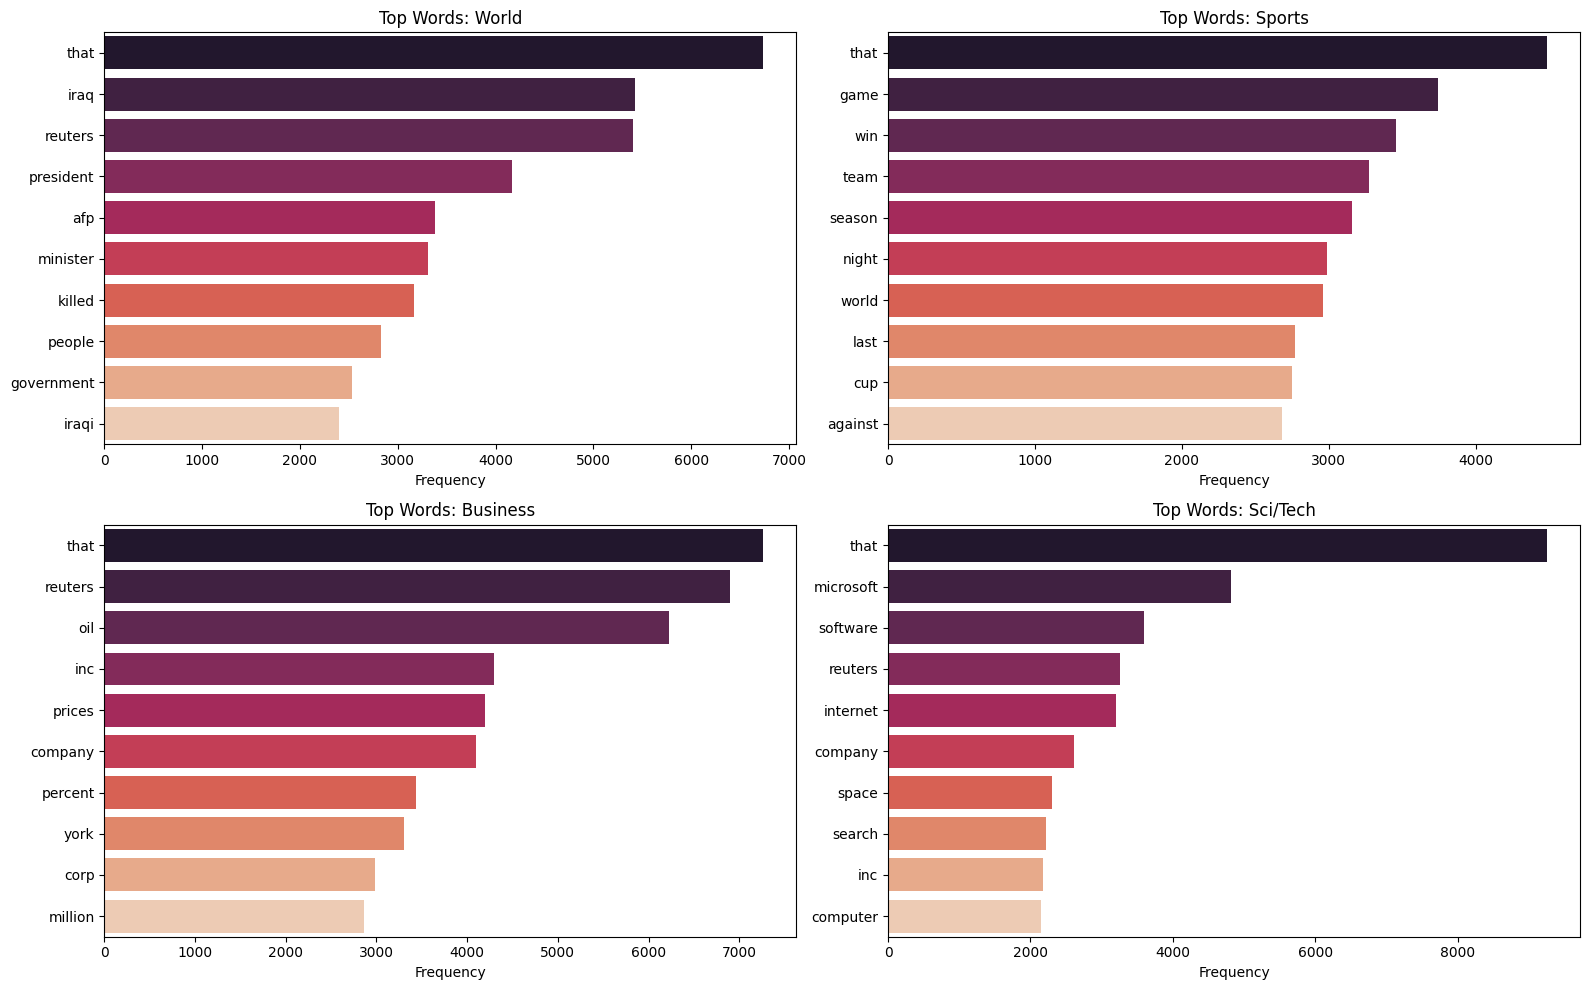

EDA complete. Plots saved to reports/


In [6]:
# We use Python's Counter to find top words after basic cleaning
import re
from collections import Counter

def get_top_words(texts, n=10):
    """
    Join a collection of texts, extract alphabetic words, and count frequencies.

    Steps performed:
      1. Concatenate all texts into one lower-case string.
      2. Remove non-alphabetic characters (keep only a-z and spaces).
      3. Filter out a manual stop-word list and words shorter than 3 chars.
      4. Return the n most common remaining words with their counts.

    Parameters
    ----------
    texts : pd.Series or array-like
        Collection of text samples (e.g. article bodies for one category).
    n : int, optional
        Number of top words to return (default 10).

    Returns
    -------
    list[tuple[str, int]]
        A list of (word, count) tuples sorted by descending frequency.
    """
    all_text = ' '.join(texts.astype(str)).lower()
    # Keep only letters and spaces
    all_text = re.sub(r'[^a-z\s]', '', all_text)
    # Remove common stop words manually 
    stop_words = {'the', 'and', 'for', 'are', 'but', 'not', 'you', 'all', 'can', 'had', 'her', 'was', 'one', 'our', 'out', 'day', 'get', 'has', 'him', 'his', 'how', 'man', 'new', 'now', 'old', 'see', 'two', 'way', 'who', 'boy', 'did', 'its', 'let', 'put', 'say', 'she', 'too', 'use', 'with', 'have', 'this', 'will', 'your', 'from', 'they', 'know', 'want', 'been', 'good', 'much', 'some', 'time', 'very', 'when', 'come', 'here', 'just', 'like', 'long', 'make', 'many', 'over', 'such', 'take', 'than', 'them', 'well', 'were', 'what', 'would', 'there', 'their', 'said', 'each', 'which', 'how', 'about', 'out', 'many', 'then', 'them', 'these', 'so', 'some', 'her', 'would', 'make', 'like', 'into', 'him', 'has', 'two', 'more', 'very', 'what', 'know', 'just', 'first', 'also', 'after', 'back', 'other', 'many', 'than', 'only', 'those', 'come', 'day', 'most', 'us'}
    words = [w for w in all_text.split() if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

plt.figure(figsize=(16, 10))
for i, category in enumerate(order, 1):
    texts = train_df[train_df['category'] == category]['full_text']
    top_words = get_top_words(texts, n=10)
    words, counts = zip(*top_words)
    
    plt.subplot(2, 2, i)
    sns.barplot(
        x=list(counts),
        y=list(words),
        hue=list(words),
        palette='rocket',
        legend=False,
    )
    plt.title(f'Top Words: {category}')
    plt.xlabel('Frequency')
    
plt.tight_layout()
plt.savefig('reports/top_words_per_category.png')
plt.show()

print("EDA complete. Plots saved to reports/")


# 3. Preprocessing Pipeline

## 3.1 Text Cleaning
We combine the article title and description into a single string, then lowercase it, strip non-alphabetic characters, and collapse whitespace so the model sees clean input.

In [7]:
# Combine title + description into one field for each article.
train_df['full_text'] = train_df['title'].astype(str) + ' ' + train_df['description'].astype(str)
test_df['full_text'] = test_df['title'].astype(str) + ' ' + test_df['description'].astype(str)

# Import and apply the cleaning function from src/preprocessing
from src.preprocessing import clean_text
train_clean = train_df["full_text"].apply(clean_text)
test_clean = test_df["full_text"].apply(clean_text)

print("Sample cleaned text:")
print(train_clean.iloc[0][:200])


Sample cleaned text:
wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again


## 3.2 Tokenization & Vocabulary Building
We fit a Keras Tokenizer **only on training data** to prevent leakage. The vocabulary is capped at 20,000 words and an `<OOV>` token handles unseen words at inference time. The fitted tokenizer is saved to `models/tokenizer.pickle` for reuse.

In [8]:
# Fit the tokenizer ONLY on training data to prevent leakage.
from src.preprocessing import build_tokenizer

tokenizer = build_tokenizer(
    train_clean,
    max_words=20000,
    save_path='models/tokenizer.pickle'
)


Tokenizer saved. Vocabulary size: 91344


## 3.3 Sequence Padding
Articles vary in length, so we pad every sequence to 128 tokens. We use **post-padding** (zeros at the end) so the LSTM reads the sentence start first.

In [9]:
# Convert texts to integer sequences and pad/truncate to fixed length.
from src.preprocessing import prepare_sequences

MAX_LEN = 128
X_train = prepare_sequences(train_clean, tokenizer, max_len=MAX_LEN)
X_test = prepare_sequences(test_clean, tokenizer, max_len=MAX_LEN)

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")


X_train shape: (120000, 128)
X_test  shape: (7600, 128)


## 3.4 Label Preparation
The raw AG News CSV stores labels as 1-based integers (`1` = World, `2` = Sports, `3` = Business, `4` = Sci/Tech). Keras expects 0-based one-hot vectors, so we subtract 1 and apply `to_categorical`.

In [10]:
# AG News uses 1-based labels (1-4). Subtract 1 and one-hot encode for Keras.
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(train_df['class_index'] - 1, num_classes=4)
y_test_oh = to_categorical(test_df['class_index'] - 1, num_classes=4)


## 3.5 Train/Validation Split
We reserve 10 % of the training data as a validation set. The split is **stratified** so each news category appears in the same proportion as the full training set.

In [11]:
# 3.5 Train/Validation Split
# 90/10 stratified split keeps class proportions identical in both sets.
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_oh, test_size=0.1, random_state=42, stratify=y_train_oh
)

print(f"Train      : {X_tr.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")


Train      : (108000, 128)
Validation : (12000, 128)
Test       : (7600, 128)


## 3.6 Saving Arrays
We export the six final NumPy arrays (`X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`) to `data/processed/` so teammates can load them directly without re-running preprocessing.

In [12]:
# Export the six final arrays so teammates can skip preprocessing.
import os
import numpy as np

save_dir = 'data/processed'
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, 'X_train.npy'), X_tr)
np.save(os.path.join(save_dir, 'y_train.npy'), y_tr)
np.save(os.path.join(save_dir, 'X_val.npy'), X_val)
np.save(os.path.join(save_dir, 'y_val.npy'), y_val)
np.save(os.path.join(save_dir, 'X_test.npy'), X_test)
np.save(os.path.join(save_dir, 'y_test.npy'), y_test_oh)

print(f"Arrays saved to {save_dir}/")
print(f"  Train      : {X_tr.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Test       : {X_test.shape}")
print(f"  Vocab size : {len(tokenizer.word_index)}")


Arrays saved to data/processed/
  Train      : (108000, 128)
  Validation : (12000, 128)
  Test       : (7600, 128)
  Vocab size : 91344


# 4. Model from Scratch (Keras)

## 4.0 Verify TensorFlow + GPU

Confirm the active kernel is the `tf210` env (TensorFlow 2.10, Python 3.10) and that it sees the RTX 3060. If `num_gpus` is `0`, switch kernels in the top-right corner of the notebook.

In [13]:
# 4.0 Verify TensorFlow + GPU are properly configured.
# Run this in the tf210 conda env (Python 3.10 + TF 2.10 + CUDA 11.2 + cuDNN 8.1).
from src.model_builder import verify_gpu
info = verify_gpu()

assert info["num_gpus"] >= 1, (
    "No GPU detected. Check that the active kernel is 'Python 3.10 (tf210)' "
    "and that conda installed cudatoolkit=11.2 + cudnn=8.1."
)

     tf_version: 2.10.1
built_with_cuda: True
       num_gpus: 1
    device_name: /physical_device:GPU:0


## 4.1 Load preprocessed arrays from data/processed/

In [14]:
import numpy as np

DATA_DIR = "data/processed"
X_train = np.load(f"{DATA_DIR}/X_train.npy")
y_train = np.load(f"{DATA_DIR}/y_train.npy")
X_val   = np.load(f"{DATA_DIR}/X_val.npy")
y_val   = np.load(f"{DATA_DIR}/y_val.npy")
X_test  = np.load(f"{DATA_DIR}/X_test.npy")
y_test  = np.load(f"{DATA_DIR}/y_test.npy")

# Derive shape constants directly from the data so the model auto-adapts
# if preprocessing settings change later.
VOCAB_SIZE  = int(X_train.max()) + 1      # max token id + 1 (post-padded 0s reserved)
MAX_LEN     = X_train.shape[1]            # 128
NUM_CLASSES = y_train.shape[1]            # 4

print(f"X_train: {X_train.shape}  dtype={X_train.dtype}")
print(f"y_train: {y_train.shape}  dtype={y_train.dtype}  (one-hot)")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")
print(f"\nDerived constants:")
print(f"  VOCAB_SIZE  = {VOCAB_SIZE}")
print(f"  MAX_LEN     = {MAX_LEN}")
print(f"  NUM_CLASSES = {NUM_CLASSES}")

X_train: (108000, 128)  dtype=int32
y_train: (108000, 4)  dtype=float32  (one-hot)
X_val  : (12000, 128)
X_test : (7600, 128)

Derived constants:
  VOCAB_SIZE  = 20000
  MAX_LEN     = 128
  NUM_CLASSES = 4


## 4.2 Build the scratch BiLSTM model
### Architecture: Embedding -> SpatialDropout -> BiLSTM -> GlobalMaxPool -> Dense -> Softmax

In [15]:
from src.model_builder import build_lstm_model

EMBEDDING_DIM = 128
LSTM_UNITS    = 64
DROPOUT_RATE  = 0.5
LEARNING_RATE = 1e-3

model = build_lstm_model(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    maxlen=MAX_LEN,
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE,
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
)
model.summary()

Model: "ag_news_lstm"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_ids (InputLayer)      [(None, 128)]             0         
                                                                 
 embedding (Embedding)       (None, 128, 128)          2560000   
                                                                 
 spatial_dropout (SpatialDro  (None, 128, 128)         0         
 pout1D)                                                         
                                                                 
 bi_lstm (Bidirectional)     (None, 128, 128)          98816     
                                                                 
 global_max_pool (GlobalMaxP  (None, 128)              0         
 ooling1D)                                                       
                                                                 
 dense_relu (Dense)          (None, 64)               

## 4.3 Train with EarlyStopping + ReduceLROnPlateau + ModelCheckpoint

In [16]:
# 4.3 Train with EarlyStopping + ReduceLROnPlateau + ModelCheckpoint
import os, time, json
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

BATCH_SIZE = 256        # RTX 3060 12 GB can comfortably handle this
EPOCHS     = 10         # EarlyStopping will usually halt around epoch 4-6

callbacks = [
    EarlyStopping(
        monitor="val_accuracy", patience=3,
        restore_best_weights=True, verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2,
        min_lr=1e-5, verbose=1,
    ),
    ModelCheckpoint(
        # TF 2.10 prefers the SavedModel directory format or .h5; .keras is a
        # Keras-3-only format and won't load back in tf.keras.
        "models/lstm_scratch.h5",
        monitor="val_accuracy", save_best_only=True, verbose=1,
    ),
]

start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)
elapsed = time.time() - start
print(f"\nTraining time: {elapsed:.1f}s  ({elapsed/60:.2f} min)")

# Persist history for later comparison with the BERT model (section 7.4).
with open("models/lstm_scratch_history.json", "w") as f:
    json.dump(
        {k: [float(x) for x in v] for k, v in history.history.items()},
        f, indent=2,
    )
print("Saved: models/lstm_scratch.h5")
print("Saved: models/lstm_scratch_history.json")

Epoch 1/10
421/422 [============================>.] - ETA: 0s - loss: 0.4964 - accuracy: 0.8188
Epoch 1: val_accuracy improved from -inf to 0.91592, saving model to models\lstm_scratch.h5
422/422 [==============================] - 21s 38ms/step - loss: 0.4959 - accuracy: 0.8191 - val_loss: 0.2540 - val_accuracy: 0.9159 - lr: 0.0010
Epoch 2/10
421/422 [============================>.] - ETA: 0s - loss: 0.2348 - accuracy: 0.9278
Epoch 2: val_accuracy improved from 0.91592 to 0.92158, saving model to models\lstm_scratch.h5
422/422 [==============================] - 17s 41ms/step - loss: 0.2349 - accuracy: 0.9278 - val_loss: 0.2366 - val_accuracy: 0.9216 - lr: 0.0010
Epoch 3/10
421/422 [============================>.] - ETA: 0s - loss: 0.1834 - accuracy: 0.9428
Epoch 3: val_accuracy did not improve from 0.92158
422/422 [==============================] - 16s 39ms/step - loss: 0.1835 - accuracy: 0.9428 - val_loss: 0.2469 - val_accuracy: 0.9213 - lr: 0.0010
Epoch 4/10
422/422 [================

## 4.4 Plot training curves and run a quick test-set evaluation


Test loss     : 0.2496
Test accuracy : 0.9172


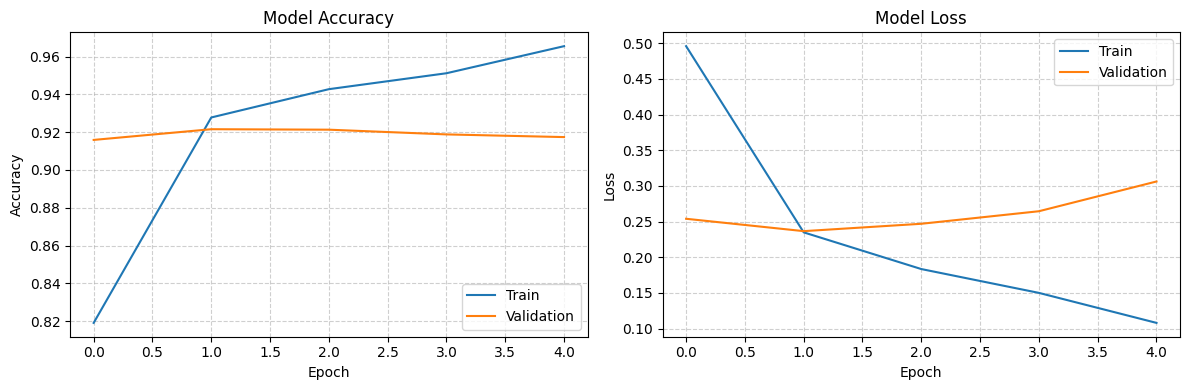

In [17]:
from src.utils import plot_training_history

fig = plot_training_history(
    history.history,
    save_path="reports/lstm_scratch_training.png",
)

# Quick sanity check on the test set (full evaluation is in section 7).
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
print(f"\nTest loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

# 5. Pretrained Model (DistilBERT Fine-Tuning)
## 5.1 Tokenization for BERT
## 5.2 Model Setup & Layer Freezing
## 5.3 Fine-Tuning & History

In [ ]:
# TODO: Import transformers (DistilBertTokenizer, TFDistilBertForSequenceClassification)
# TODO: Tokenize raw text for BERT (truncation, padding, max_length=128)
# TODO: Load pretrained model, freeze first 4 layers
# TODO: Compile with low learning rate (2e-5)
# TODO: Train with EarlyStopping, plot curves

# 6. Hyperparameter Tuning
## 6.1 Search Space
## 6.2 Best Configuration
## 6.3 Retrained Final Model

In [ ]:
# TODO: Import keras_tuner
# TODO: Define build_hp_model() with tunable embedding_dim, lstm_units, dropout, learning_rate
# TODO: Run RandomSearch or BayesianOptimization
# TODO: Print best hyperparameters
# TODO: Train final model with best config

# 7. Model Evaluation & Interpretation
## 7.1 Test Set Evaluation
## 7.2 Confusion Matrix
## 7.3 Per-Class Metrics
## 7.4 Scratch vs. BERT Comparison

In [ ]:
# TODO: Load both saved models from models/
# TODO: Evaluate on test set (model.evaluate)
# TODO: Generate predictions (model.predict)
# TODO: Classification report and confusion matrix for both models
# TODO: Create comparison dataframe (Accuracy, F1, Params, Training Time)

# 8. Final Report
## 8.1 Results Interpretation
## 8.2 Hardware & Memory Details
## 8.3 Next Steps
## 8.4 Lessons Learned
## 8.5 Team Contributions

### 8.1 Results Interpretation
*Write your analysis here after running the models. Discuss Business vs Sci/Tech confusion and business impact.*

### 8.2 Hardware & Memory Details
- CPU/GPU used:
- RAM available:
- Training time per epoch (scratch):
- Training time per epoch (BERT):
- Model size on disk:

### 8.3 Next Steps
*Suggestions for continuing the project: real-time API, RSS integration, multi-label support.*

### 8.4 Lessons Learned
*3-5 bullet points on technical and project management takeaways.*

### 8.5 Team Contributions
| Member | Contribution |
|--------|--------------|
| 1 | |
| 2 | |
| 3 | |
| 4 | |
| 5 | |
| 6 | |